In [2]:
# import sys
# !{sys.executable} -m pip install lifelines

In [3]:
from pycox.models import CoxPH
from pycox.utils import kaplan_meier
from torchtuples import optim
from sklearn_pandas import DataFrameMapper
from sklearn.preprocessing import StandardScaler
from lifelines.statistics import logrank_test

import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torchtuples as tt
import numpy as np
import pandas as pd

In [4]:
# np.random.seed(1234)
# _ = torch.manual_seed(123)

In [5]:
data_file_path = 'data/hodgkins_disease.csv'
df = pd.read_csv(data_file_path)

In [6]:
df.describe()

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
count,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000
mean,35.304775,0.464740,0.091329,0.657803,0.332948,0.536416,0.287861,12.863565,0.648555
std,15.464521,0.499044,0.288244,0.474719,0.471541,0.498961,0.453028,9.304421,0.735320
min,15.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003000,0.000000
25%,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,30.620000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,14.000000,0.000000
75%,43.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,20.300000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.900000,2.000000


In [7]:
for col in df:
    print(col)
    print(df[col].nunique())

age
229
female
2
extranod
2
stage2
2
medwidsi_S
2
medwidsi_N
2
chemo
2
time
281
status
3


In [8]:
df_test = df.sample(frac=0.2)
df_train = df.drop(df_test.index)
df_val = df_train.sample(frac=0.2)
df_train = df_train.drop(df_val.index)

## Data Processing

In [9]:
for col in df:
    print(col)
    print(df[col].nunique())

age
229
female
2
extranod
2
stage2
2
medwidsi_S
2
medwidsi_N
2
chemo
2
time
281
status
3


In [10]:
print(df.columns)

Index(['age', 'female', 'extranod', 'stage2', 'medwidsi_S', 'medwidsi_N',
       'chemo', 'time', 'status'],
      dtype='object')


In [11]:
covariates_cols = [
    "age",
    "female",
    "extranod",
    "stage2",
    "medwidsi_S",
    "medwidsi_N",
    "chemo",
]

In [12]:
cols_standardize = ['age']
cols_leave = ['female', 'extranod', 'stage2', 'medwidsi_S', 'medwidsi_N',
       'chemo']

standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

print(standardize + leave)

x_mapper = DataFrameMapper(standardize + leave)

[(['age'], StandardScaler()), ('female', None), ('extranod', None), ('stage2', None), ('medwidsi_S', None), ('medwidsi_N', None), ('chemo', None)]


In [13]:
x_train = x_mapper.fit_transform(df_train).astype('float32')
x_val = x_mapper.transform(df_val).astype('float32')
x_test = x_mapper.transform(df_test).astype('float32')
x_all = x_mapper.transform(df).astype('float32')

In [14]:
get_target = lambda df: (df['time'].values, df['status'].values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = x_val, y_val

times, events = get_target(df)

## Net

In [15]:
in_features = x_train.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1
output_bias = False

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)

# net = nn.Sequential(
#     nn.Linear(len(covariates_cols), 32),
#     nn.ReLU(),
#     nn.Linear(32, 1)
# )

## Training

In [16]:
model = CoxPH(net, tt.optim.Adam)

In [17]:
model.optimizer.set_lr(0.01)

In [18]:
epochs = 512
callbacks = [tt.callbacks.EarlyStopping()]
verbose = True
batch_size = 256

In [19]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val, val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.5587,	val_loss: 4.1863
1:	[0s / 0s],		train_loss: 4.2830,	val_loss: 4.1562
2:	[0s / 0s],		train_loss: 4.2936,	val_loss: 4.1615
3:	[0s / 0s],		train_loss: 4.1691,	val_loss: 4.1813
4:	[0s / 0s],		train_loss: 4.2323,	val_loss: 4.1688
5:	[0s / 0s],		train_loss: 4.2200,	val_loss: 4.1565
6:	[0s / 0s],		train_loss: 4.2491,	val_loss: 4.1299
7:	[0s / 0s],		train_loss: 4.1816,	val_loss: 4.1132
8:	[0s / 0s],		train_loss: 4.2179,	val_loss: 4.0961
9:	[0s / 0s],		train_loss: 4.1168,	val_loss: 4.0790
10:	[0s / 0s],		train_loss: 4.3262,	val_loss: 4.0685
11:	[0s / 0s],		train_loss: 4.1651,	val_loss: 4.0870
12:	[0s / 0s],		train_loss: 4.1700,	val_loss: 4.0917
13:	[0s / 0s],		train_loss: 4.2166,	val_loss: 4.0886
14:	[0s / 0s],		train_loss: 4.1730,	val_loss: 4.0744
15:	[0s / 0s],		train_loss: 4.2003,	val_loss: 4.0671
16:	[0s / 0s],		train_loss: 4.2103,	val_loss: 4.0729
17:	[0s / 0s],		train_loss: 4.1862,	val_loss: 4.0817
18:	[0s / 0s],		train_loss: 4.1784,	val_loss: 4.0771
19:

In [20]:
x_all[0]

array([1.8362814, 1.       , 0.       , 0.       , 0.       , 1.       ,
       0.       ], dtype=float32)

## Treatment Rec Evaluation

In [21]:
treatment_col_index = 6

recommendation_times = []
recommendation_events = []
anti_recommendation_times = []
anti_recommendation_events = []

for x, t, e in zip(x_all, times, events):
    risks = []
    real_treatment = x[treatment_col_index]
    
    x_without_treatment = np.copy(x)
    x_without_treatment[treatment_col_index] = 0
    risks.append(model.predict(x_without_treatment.reshape(1, -1)))

    x_with_treatment = np.copy(x)
    x_with_treatment[treatment_col_index] = 1
    risks.append(model.predict(x_with_treatment.reshape(1, -1)))

    predicted_treatment = np.argmin(risks)

    if real_treatment == predicted_treatment: 
        recommendation_times.append(t)
        recommendation_events.append(t)
    if real_treatment != predicted_treatment: 
        anti_recommendation_times.append(t)
        anti_recommendation_events.append(t)


In [22]:
km_rec = kaplan_meier(np.array(recommendation_times), np.array(recommendation_events))
km_anti = kaplan_meier(np.array(anti_recommendation_times), np.array(anti_recommendation_events))

/opt/homebrew/lib/python3.11/site-packages/pycox/utils.py:74: RuntimeWarning: invalid value encountered in log
  surv[:i] = np.exp(np.log(survive[:i]).cumsum())
/opt/homebrew/lib/python3.11/site-packages/pycox/utils.py:78: RuntimeWarning: invalid value encountered in log
  surv = np.exp(np.log(1 - di / ni).cumsum())


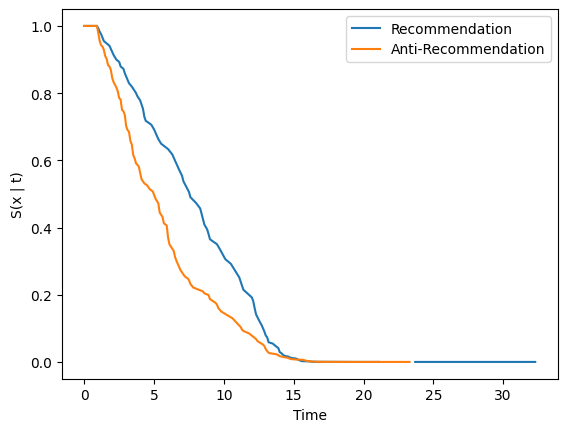

In [23]:
km_rec.name = "Recommendation"
km_anti.name = "Anti-Recommendation"
plt.plot(km_rec, label=km_rec.name)
plt.plot(km_anti, label=km_anti.name)

plt.xlabel("Time")
plt.ylabel("S(x | t)")
plt.legend()
plt.show()

In [24]:
result = logrank_test(recommendation_times, anti_recommendation_times, recommendation_events, anti_recommendation_events)

In [25]:
print(result.p_value)

0.026517716386718578


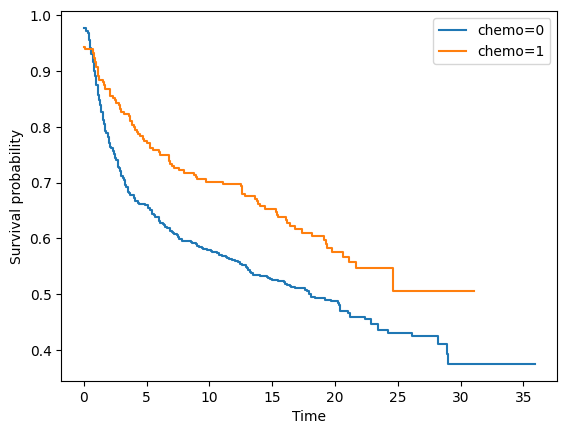

In [26]:
from sksurv.nonparametric import kaplan_meier_estimator
import matplotlib.pyplot as plt
import pandas as pd

km_results = []

time, status = df["time"].values, df["status"].values.astype(bool)

for label in df["chemo"].unique():
    mask = df["chemo"] == label
    t, s = kaplan_meier_estimator(status[mask], time[mask])
    df_km = pd.DataFrame({
        "time": t,
        "survival": s,
        "chemo": label
    })
    km_results.append(df_km)
    plt.step(t, s, where="post", label=f"chemo={label}")
km_all = pd.concat(km_results, ignore_index=True)
output_path = r"D:\NCKH\p_value_metabric.csv"
km_all.to_csv(output_path, index=False)

plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.legend()
plt.show()